In [85]:
import xarray as xr
import regionmask
import pandas as pd

In [2]:
centres = {
    "ecmwf": ["51"],
    "meteo_france": ["9"],
    "ukmo": ["610"],
    "dwd": ["22"],
    "cmcc": ["4"],
    "ncep": ["2"],
    "jma": ["4"],
    "eccc": ["4", "5"],
    "bom": ["2"],
}

region_sel = "SAS"

In [78]:
import zipfile

datatype_to_product = {
    "em": "ensemble_mean",
    "hcmean": "hindcast_climate_mean",
    "fcmean": "monthly_mean",
    "fcmax": "monthly_maximum",
    "fcmin": "monthly_minimum",
    "fcstdev": "monthly_standard_deviation",
}


def zip_to_datatree(zip_path, extract_dir):
    with zipfile.ZipFile(zip_path) as z:
        names = z.namelist()
        z.extractall(extract_dir)

    tree_dict = {}
    for name in names:
        ds = xr.open_dataset(f"{extract_dir}/{name}")
        dtype = ds["t2m"].attrs["GRIB_dataType"]
        key = datatype_to_product.get(dtype, dtype)
        tree_dict[key] = ds

    return xr.DataTree.from_dict(tree_dict)


def land_only(da):
    land_mask = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(da)
    da_land_only = da.where(land_mask.notnull())
    return da_land_only

In [4]:
trees = {}
for centre, systems in centres.items():
    for system in systems:
        path = f"/home/emily_zuetell/projects/poreallas/scripts//data/raw/2607_{centre}_s{system}.nc"
        extract_dir = path.replace(".nc", "_extracted")

        var = f"{centre}_s{system}"
        trees[var] = zip_to_datatree(path, extract_dir)

# Map

In [ ]:
# TODO switch to xesmf
def regrid_to_target(da, target):
    return da.interp(
        latitude=target.latitude, longitude=target.longitude, method="linear"
    )

In [80]:
def compute_anomaly(tree):
    forecast = tree["ensemble_mean"]["t2m"]
    climatology = tree["hindcast_climate_mean"]["t2m"]
    anomaly = land_only(forecast - climatology)
    return anomaly.rename("t2m_anomaly")

In [81]:
anomalies = {cs: compute_anomaly(tree) for cs, tree in trees.items()}

target_grid = anomalies["ecmwf_s51"]
regridded = {
    cs: (da if cs == "ecmwf_s51" else regrid_to_target(da, target_grid))
    for cs, da in anomalies.items()
}

combined_anomaly = xr.concat(
    regridded.values(), dim=pd.Index(regridded.keys(), name="centre_system")
)

In [82]:
diff = combined_anomaly.sel(centre_system="ecmwf_s51") - combined_anomaly

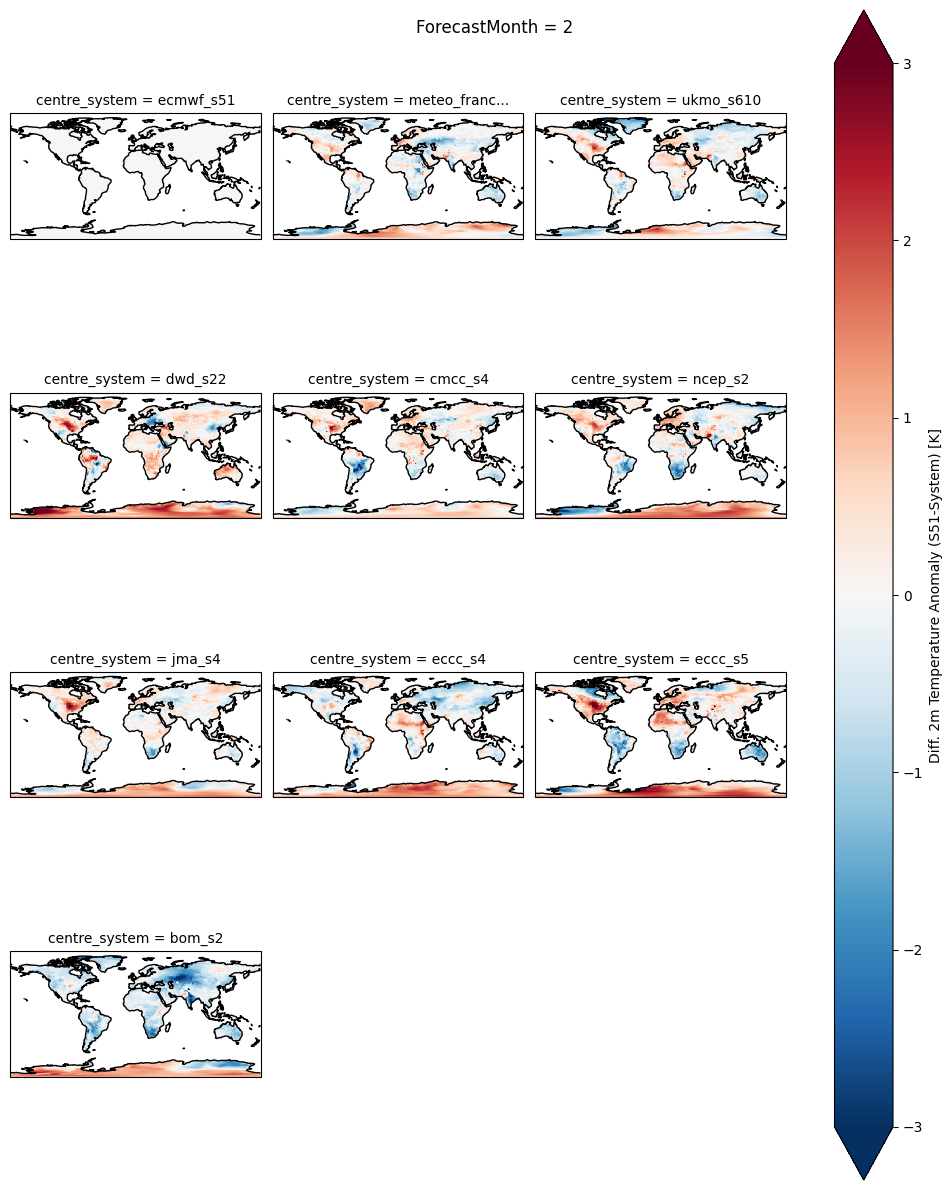

In [84]:
import cartopy.crs as ccrs

p = diff.sel(forecastMonth=2).plot(
    col="centre_system",
    col_wrap=3,
    vmin=-3,
    vmax=3,
    cmap="RdBu_r",
    cbar_kwargs={"label": "Diff. 2m Temperature Anomaly (S51-System) [K]"},
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(),
)
p.fig.suptitle("ForecastMonth = 2")
for ax in p.axs.flat:
    ax.coastlines()

# Multi-System Spread

In [66]:
system_std = combined_anomaly.std("centre_system")

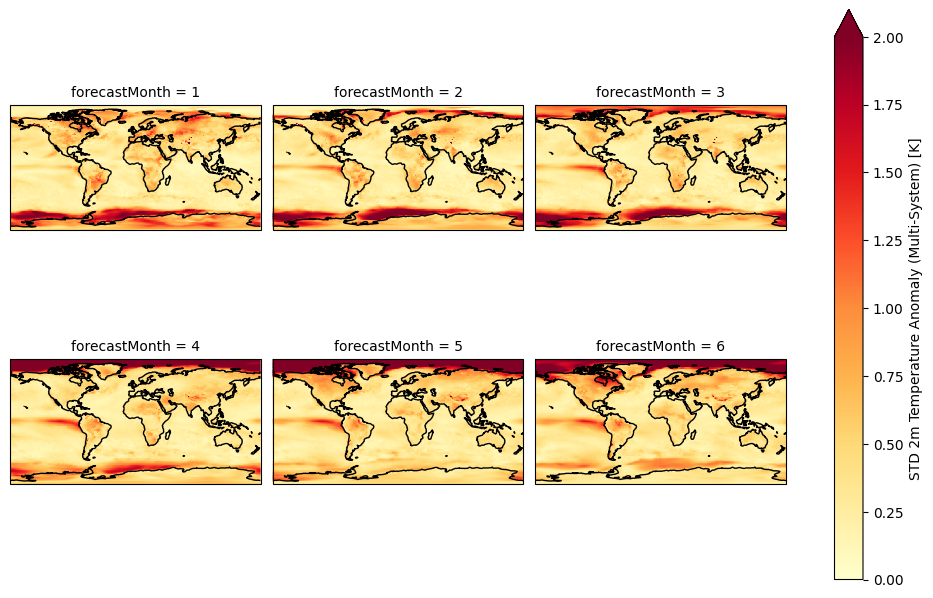

In [73]:
p = system_std.plot(
    col="forecastMonth",
    col_wrap=3,
    vmin=0,
    vmax=2,
    cmap="YlOrRd",
    cbar_kwargs={"label": "STD 2m Temperature Anomaly (Multi-System) [K]"},
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(),
)
for ax in p.axs.flat:
    ax.coastlines()

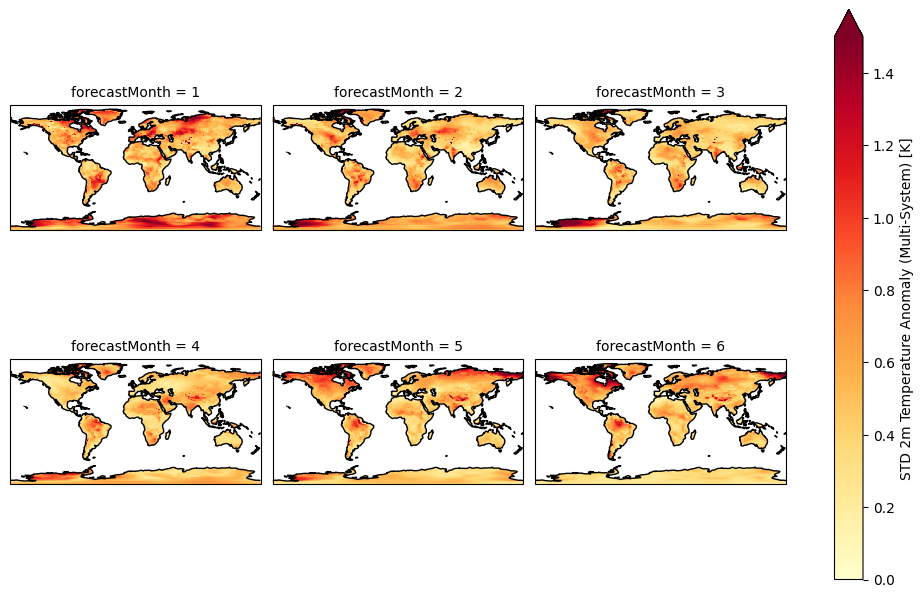

In [76]:
p = da_land_only.plot(
    col="forecastMonth",
    col_wrap=3,
    vmin=0,
    vmax=1.5,
    cmap="YlOrRd",
    cbar_kwargs={"label": "STD 2m Temperature Anomaly (Multi-System) [K]"},
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(),
)
for ax in p.axs.flat:
    ax.coastlines()

# Regional Boxplots

In [ ]:
import pandas as pd

# e.g. AR6 land regions
ar6_regions = regionmask.defined_regions.ar6.land


def select_region(da):
    mask = ar6_regions.mask(da)
    region_da = da.where(mask == ar6_regions.map_keys(region_sel))
    return region_da


records = []
for centre_system, tree in trees.items():  # e.g. key = "ecmwf_s51"
    da = tree["monthly_mean"]["t2m"]
    da_hc = tree["hindcast_climate_mean"]["t2m"]
    # select region
    da = select_region(da)
    da_hc = select_region(da_hc)
    df = (da - da_hc).to_dataframe().reset_index()
    df["centre_system"] = centre_system
    records.append(df[["centre_system", "forecastMonth", "t2m"]])

plot_df = pd.concat(records, ignore_index=True)

In [ ]:
records_em = []
for centre_system, tree in trees.items():
    da = tree["ensemble_mean"]["t2m"]
    da_hc = tree["hindcast_climate_mean"]["t2m"]
    # select region
    da = select_region(da)
    da_hc = select_region(da_hc)

    df = (da - da_hc).to_dataframe().reset_index()
    df["centre_system"] = centre_system
    records_em.append(df[["centre_system", "forecastMonth", "t2m"]])

em_df = pd.concat(records_em, ignore_index=True)

In [ ]:
import seaborn as sns

g = sns.catplot(
    data=plot_df,
    y="centre_system",
    x="t2m",
    col="forecastMonth",
    kind="box",
    orient="h",
    height=5,
    aspect=0.5,
)
for ax, month in zip(g.axes.flat, g.col_names):
    vals = em_df.loc[em_df["forecastMonth"] == month, "t2m"]
    # q1, med, q3 = vals.quantile([0.25, 0.5, 0.75])
    # ax.axvspan(q1, q3, color="black", alpha=0.15, zorder=10)
    ax.axvline(vals.mean(), color="black", linewidth=1.5, zorder=11)
    ax.set_xlabel("t2m anomaly")
g.fig.suptitle(f"T2M Anomaly: AR6 Region = {region_sel}", y=1.02)
g.fig